# UR3e Rollout Log Plots

Reads the CSV rollout log written by `run_policy_loop()` in `ur3e_policy_deploy.py`
(columns: `timestamp`, `pos_<joint>` x6, `vel_<joint>` x6) and plots:

1. Joint position vs. time
2. Joint velocity vs. time

Set `LOG_PATH` below to point at your log file, then run all cells.

In [1]:
import csv
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# Path to the rollout log CSV produced by ur3e_policy_deploy.py
LOG_PATH = "real_rollout_log_3_0_3.txt"

In [9]:
def load_log(log_path):
    with open(log_path, "r", newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        rows = [row for row in reader if row]

    timestamps = [float(row[0]) for row in rows]

    pos_cols = [i for i, h in enumerate(header) if h.startswith("pos_")]
    vel_cols = [i for i, h in enumerate(header) if h.startswith("vel_")]

    pos_labels = [header[i][len("pos_"):] for i in pos_cols]
    vel_labels = [header[i][len("vel_"):] for i in vel_cols]

    # positions[j] / velocities[j] = list of values over time for joint j
    positions = [[float(row[i]) for row in rows] for i in pos_cols]
    velocities = [[float(row[i]) for row in rows] for i in vel_cols]

    return timestamps, positions, pos_labels, velocities, vel_labels


def plot_series(timestamps, series, labels, title, ylabel):
    fig, ax = plt.subplots(figsize=(10, 6))
    for values, label in zip(series, labels):
        ax.plot(timestamps, values, marker="", markersize=3, label=label)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="best", fontsize="small")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return fig

In [10]:
timestamps, positions, pos_labels, velocities, vel_labels = load_log(LOG_PATH)
print(f"Loaded {len(timestamps)} steps from {LOG_PATH}")

Loaded 1008 steps from real_rollout_log_3_0_3.txt


## Joint Position vs. Time

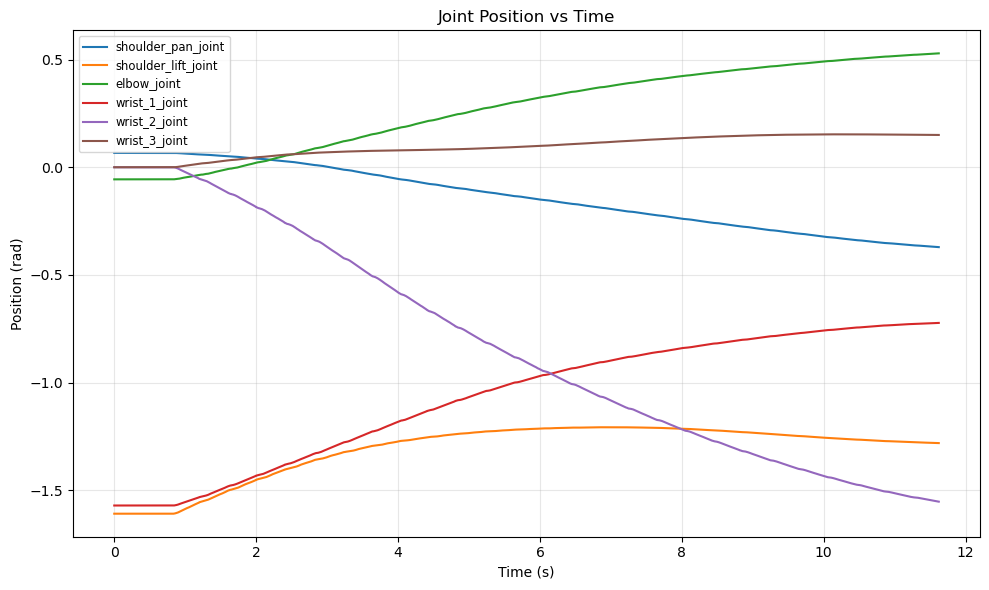

In [11]:
fig_pos = plot_series(timestamps, positions, pos_labels,
                       title="Joint Position vs Time", ylabel="Position (rad)")
plt.show()

## Joint Velocity vs. Time

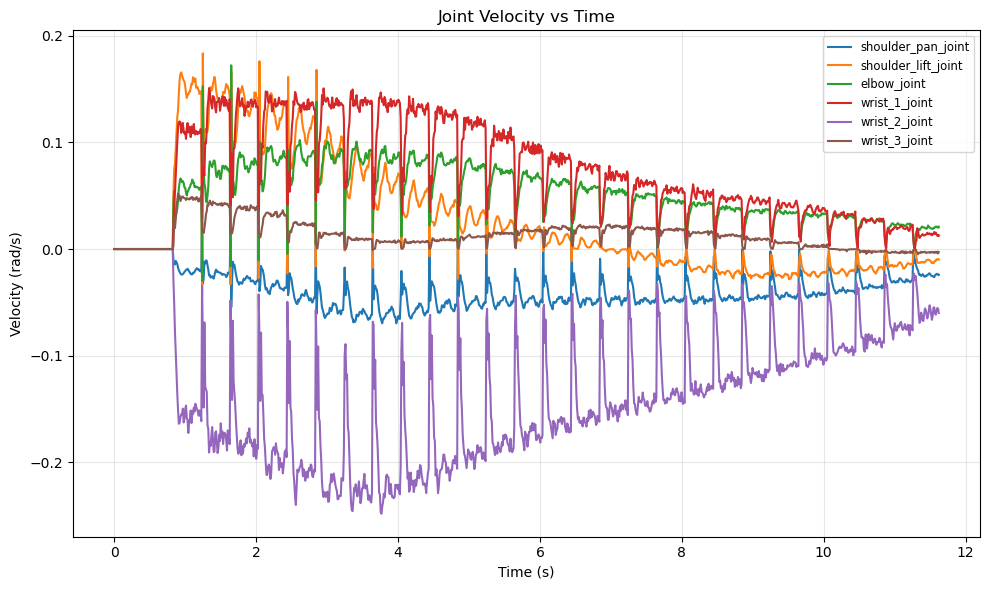

In [12]:
fig_vel = plot_series(timestamps, velocities, vel_labels,
                       title="Joint Velocity vs Time", ylabel="Velocity (rad/s)")
plt.show()

## 2 Plots 1 Fig

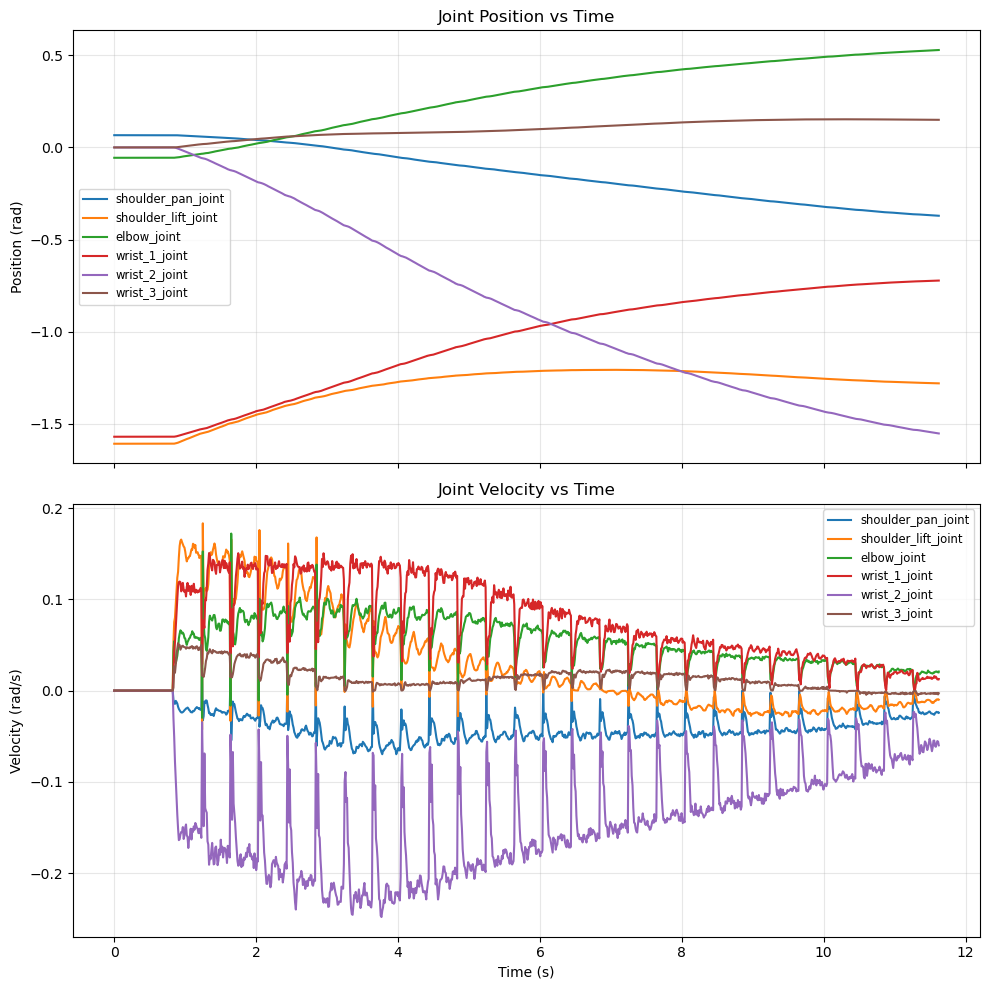

In [27]:
def load_log(log_path):
    with open(log_path, "r", newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        rows = [row for row in reader if row]
    timestamps = [float(row[0]) for row in rows]
    pos_cols = [i for i, h in enumerate(header) if h.startswith("pos_")]
    vel_cols = [i for i, h in enumerate(header) if h.startswith("vel_")]
    pos_labels = [header[i][len("pos_"):] for i in pos_cols]
    vel_labels = [header[i][len("vel_"):] for i in vel_cols]
    # positions[j] / velocities[j] = list of values over time for joint j
    positions = [[float(row[i]) for row in rows] for i in pos_cols]
    velocities = [[float(row[i]) for row in rows] for i in vel_cols]
    return timestamps, positions, pos_labels, velocities, vel_labels


def plot_series(ax, timestamps, series, labels, title, ylabel, xlabel=None):
    if labels:
        for values, label in zip(series, labels):
            ax.plot(timestamps, values, marker="", markersize=3, label=label)
    else:
        for values in series:
            ax.plot(timestamps, values, marker="", markersize=3)
    if xlabel:
        ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="best", fontsize="small")
    ax.grid(True, alpha=0.3)


fig, (ax_pos, ax_vel) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

plot_series(ax_pos, timestamps, positions,
            title="Joint Position vs Time", labels=pos_labels, ylabel="Position (rad)")

plot_series(ax_vel, timestamps, velocities, labels=vel_labels,
            title="Joint Velocity vs Time", ylabel="Velocity (rad/s)",
            xlabel="Time (s)")

fig.tight_layout()
plt.show()

## Optional: save figures to disk

Uncomment and run to save the two figures as PNGs next to this notebook.

In [ ]:
# fig_pos.savefig("rollout_position.png", dpi=150)
# fig_vel.savefig("rollout_velocity.png", dpi=150)